# Assignment 2: Nearest neighbours and Decision Trees on UNSW-NB15 dataset

Darren Dube
BDatSci (Statistical Learning)
Stellenbosch, South Africa
27041123@sun.ac.za

## Imports and loading of data

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
features_df = pd.read_csv('features.csv')
network_traffic_df = pd.read_csv('networkTraffic.csv', na_values='?')
attack_df = pd.read_csv('attack_category_map.csv')

## EDA (identification of data quality issues)

In [18]:
network_traffic_df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,1,0.000011,udp,NaN,INT,2,0,496,0,90909.090200,...,1,1,2,0,0,0,1,2,0,0
1,2,0.000008,udp,NaN,INT,2,0,1762,0,125000.000300,...,1,1,2,0,0,0,1,2,0,0
2,3,0.000005,udp,NaN,INT,2,0,1068,0,200000.005100,...,1,1,3,0,0,0,1,3,0,0
3,4,0.000006,udp,NaN,INT,2,0,900,0,166666.660800,...,2,1,3,0,0,0,2,3,0,0
4,5,0.000010,udp,NaN,INT,2,0,2126,0,100000.002500,...,2,1,3,0,0,0,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257668,257669,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,24,13,24,0,0,0,24,24,0,9
257669,257670,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,...,1,1,2,0,0,0,1,1,0,8
257670,257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,3,13,0,0,0,3,12,0,9
257671,257672,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,30,14,30,0,0,0,30,30,0,9


In [31]:
# number of missing values for 'service' descriptive feature
network_traffic_df['service'].isna().sum()

141321

Text(0.5, 1.0, 'Correlation Heatmap of top 12 correlated features')

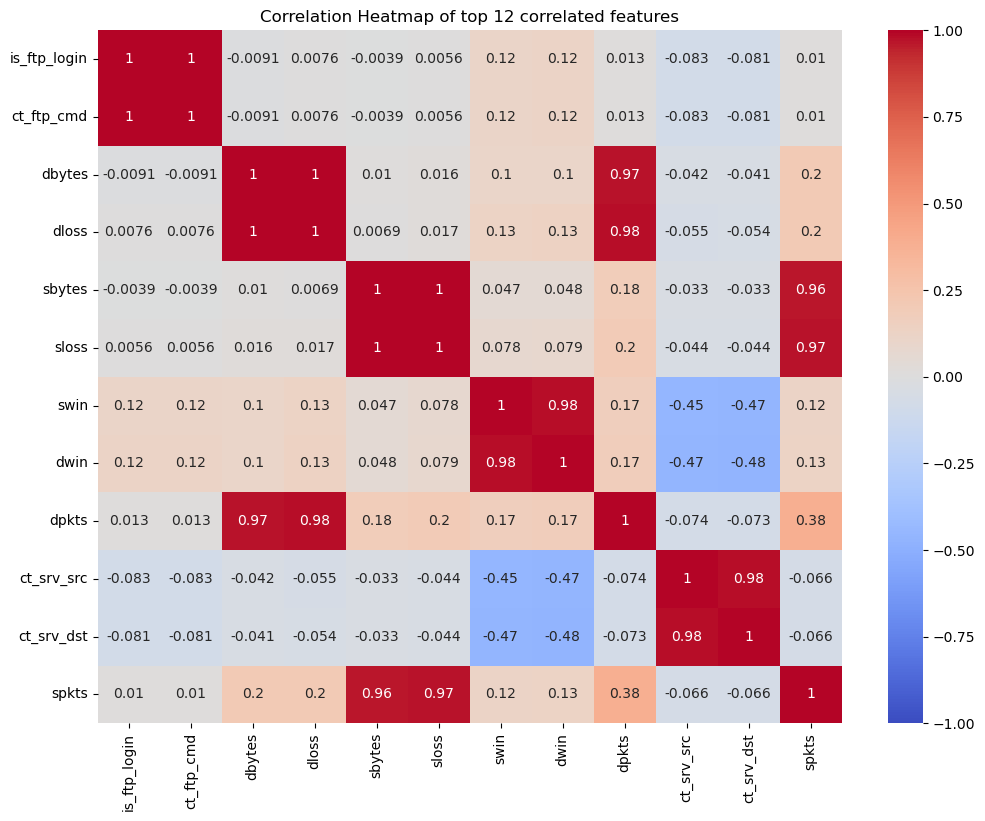

In [58]:
# compute correlation matrix for numerical features
corr_matrix = network_traffic_df.select_dtypes(include=["number"]).corr()
abs_corr = corr_matrix.abs()
top_features = (corr_matrix.abs() - np.eye(corr_matrix.shape[0])).max().nlargest(12).index
corr_matrix = corr_matrix.loc[top_features, top_features]
plt.figure(figsize=(12,9))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of top 12 correlated features')

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_61387/4090339572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=network_traffic_df, x='attack_cat', order=order, palette='crest', edgecolor="0.3").set_title('Class distribution of `attack_cat` target feature')


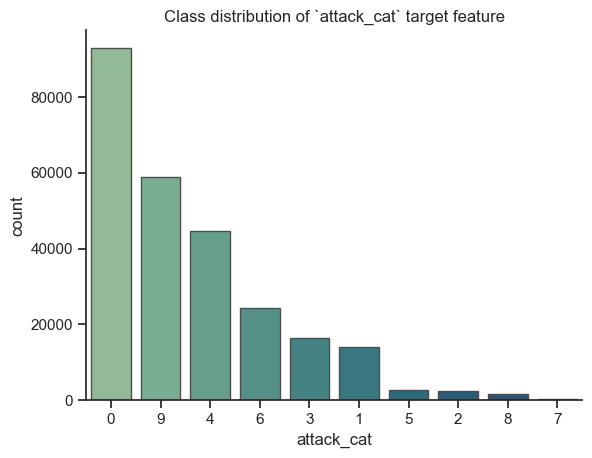

In [61]:
# class distribution of target feature
sns.set_theme(style='ticks')
order = network_traffic_df['attack_cat'].value_counts().index
ax = sns.countplot(data=network_traffic_df, x='attack_cat', order=order, palette='crest', edgecolor="0.3").set_title('Class distribution of `attack_cat` target feature')
sns.despine()

In [68]:
# outlier detection
# TODO: create a list of categorical features vs numerical (some categorical features are coded as numbers!)
count, count1 = 0, 0
for feature in network_traffic_df.select_dtypes(include="number"):
    q1, q3 = network_traffic_df[feature].quantile([0.25, 0.75])
    outliers = network_traffic_df[(network_traffic_df[feature] < q1 - 1.5 * (q3 - q1)) | (network_traffic_df[feature] > q3 + 1.5 * (q3 - q1))]
    count1 += 1
    if not outliers.empty:
        print(f"Feature '{feature}' has {len(outliers)} outliers")
        count += 1


Feature 'dur' has 21597 outliers
Feature 'spkts' has 34871 outliers
Feature 'dpkts' has 29737 outliers
Feature 'sbytes' has 32164 outliers
Feature 'dbytes' has 40024 outliers
Feature 'rate' has 23541 outliers
Feature 'sload' has 22034 outliers
Feature 'dload' has 57556 outliers
Feature 'sloss' has 16966 outliers
Feature 'dloss' has 39660 outliers
Feature 'sinpkt' has 20319 outliers
Feature 'dinpkt' has 17588 outliers
Feature 'sjit' has 23533 outliers
Feature 'djit' has 29010 outliers
Feature 'tcprtt' has 12442 outliers
Feature 'synack' has 21327 outliers
Feature 'ackdat' has 8557 outliers
Feature 'smean' has 32653 outliers
Feature 'dmean' has 33189 outliers
Feature 'trans_depth' has 25422 outliers
Feature 'response_body_len' has 16951 outliers
Feature 'ct_srv_src' has 28068 outliers
Feature 'ct_state_ttl' has 3763 outliers
Feature 'ct_dst_ltm' has 42388 outliers
Feature 'ct_src_dport_ltm' has 49014 outliers
Feature 'ct_dst_sport_ltm' has 48244 outliers
Feature 'ct_dst_src_ltm' has 4341

In [69]:
count, count1

(33, 41)